# 01 — Exploratory data analysis of SKEMPI 2.0

Look at the data before coding against it. Everything below runs from the committed
`data/processed/` tables, so it needs no GPU and no re-download.

The three questions this notebook exists to answer:

1. **What survives filtering, and why is each row dropped?**
2. **What does the ΔΔG distribution look like?** — this is what picks the loss function.
3. **How correlated are mutations within a complex?** — this is what forces the split
   decision, and it is the most important plot in the notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# Palette: one hue for one series, hairline grid, no chartjunk.
BLUE, ORANGE, AQUA, INK, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#33322f", "#e8e7e4"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "font.size": 9, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": "#7a7975", "ytick.color": "#7a7975",
    "axes.spines.top": False, "axes.spines.right": False,
})

complexes = pd.read_csv(ROOT / "data/processed/complexes.csv")
mutations = pd.read_csv(ROOT / "data/processed/mutations.csv")
splits    = pd.read_csv(ROOT / "data/processed/splits.csv")

print(f"complexes  {complexes.shape}  {list(complexes.columns)}")
print(f"mutations  {mutations.shape}")
print(f"splits     {splits.shape}")

complexes  (316, 5)  ['pdb_field', 'pdb_id', 'sequence', 'length', 'chain_offsets']
mutations  (4829, 17)
splits     (4829, 4)


## 1. The filter chain

SKEMPI ships 7,085 mutation records. Four filters take that to the modelled set. The
one worth understanding is the second.

**SKEMPI reports some affinities as bounds, not measurements** — "no detectable binding"
appears as `>1e-4` rather than a number. SKEMPI's convenience columns
(`Affinity_*_parsed`) strip the `<` / `>` and return a bare float, so filtering on missing
values alone silently keeps those rows *as if they were real measurements*. The filter has
to run against the raw `Affinity_* (M)` columns, where the marker survives.

In [2]:
chain = pd.DataFrame([
    ("all rows in SKEMPI 2.0",                7085, ""),
    ("single-point only",                     5112, "1,973 multi-point rows dropped (out of scope for v1)"),
    ("minus inequality / bounded affinity",   4985, "127 dropped -- bounds, not measurements"),
    ("minus unusable Kd at either end",       4829, "156 dropped"),
    ("minus complexes over 2,048 tokens",     4814, "15 rows / 2 complexes dropped (0.3%)"),
], columns=["filter", "rows remaining", "note"])
chain["dropped"] = -chain["rows remaining"].diff().fillna(0).astype(int)
chain[["filter", "rows remaining", "dropped", "note"]]

,filter,rows remaining,dropped,note
0,all rows in SKEMPI 2.0,7085,0,
1,single-point only,5112,1973,"1,973 multi-point rows dropped (out of scope f..."
2,minus inequality / bounded affinity,4985,127,"127 dropped -- bounds, not measurements"
3,minus unusable Kd at either end,4829,156,156 dropped
4,"minus complexes over 2,048 tokens",4814,15,15 rows / 2 complexes dropped (0.3%)


In [3]:
# The last row of the chain, recomputed here rather than asserted.
complexes["n_tokens"] = complexes["sequence"].str.len() + 2   # <cls> ... <eos>
kept = complexes[complexes["n_tokens"] <= 2048]
modelled = mutations[mutations["pdb_field"].isin(set(kept["pdb_field"]))]

print(f"all parsed        : {len(mutations):5,} mutations / {mutations.pdb_field.nunique():3} complexes")
print(f"modelled (<=2048) : {len(modelled):5,} mutations / {kept.pdb_field.nunique():3} complexes")
print()
print("excluded complexes:")
print(complexes.loc[complexes.n_tokens > 2048, ["pdb_field", "n_tokens"]].to_string(index=False))

all parsed        : 4,829 mutations / 316 complexes
modelled (<=2048) : 4,814 mutations / 314 complexes

excluded complexes:
     pdb_field  n_tokens
3VR6_ABCDEF_GH      3399
      1KBH_A_B      2122


## 2. The ΔΔG distribution — why Huber, not MSE

Positive ΔΔG means the mutation *weakens* binding. The distribution is strongly skewed
toward destabilization, and it has a genuine heavy tail: about 11% of rows are beyond
|ΔΔG| > 3 kcal/mol. Those are real measurements, not noise, so a squared penalty would let
a handful of them dominate the gradient. Hence `HuberLoss(delta=1.0)`.

In [4]:
d = mutations["ddg"]
print(f"n          {len(d):,}")
print(f"mean      {d.mean():+.3f} kcal/mol")
print(f"median    {d.median():+.3f}")
print(f"std        {d.std():.3f}")
print(f"range     {d.min():+.2f} .. {d.max():+.2f}")
print(f"|ddG| > 3  {(d.abs() > 3).mean():.1%}  ({(d.abs() > 3).sum():,} rows)")
print(f"destabilizing {(d > 0).sum():,}   stabilizing {(d < 0).sum():,}")

n          4,829
mean      +0.965 kcal/mol
median    +0.562
std        1.713
range     -12.22 .. +12.22
|ddG| > 3  11.0%  (530 rows)
destabilizing 3,612   stabilizing 1,050


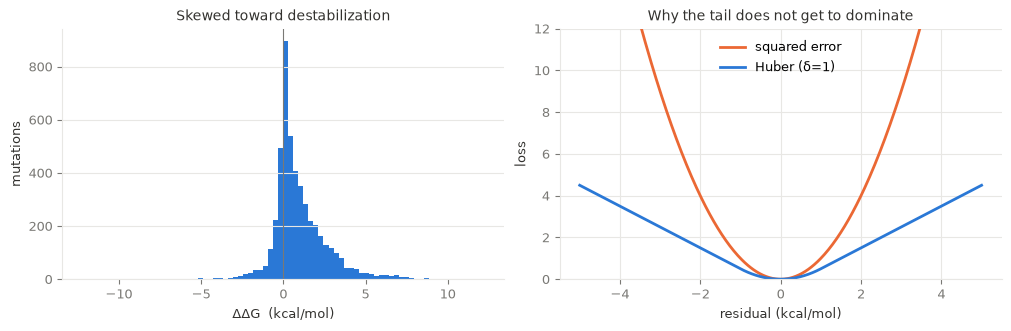

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)

ax1.hist(d, bins=80, color=BLUE, edgecolor="none")
ax1.axvline(0, color="#7a7975", lw=0.8)
ax1.set_xlabel("ΔΔG  (kcal/mol)"); ax1.set_ylabel("mutations")
ax1.set_title("Skewed toward destabilization", fontsize=10, color=INK)
ax1.grid(True, axis="y")

# Huber vs squared error on this distribution's residual scale.
r = np.linspace(-5, 5, 400)
ax2.plot(r, r ** 2, color=ORANGE, lw=2, label="squared error")
ax2.plot(r, np.where(np.abs(r) <= 1, 0.5 * r ** 2, np.abs(r) - 0.5),
         color=BLUE, lw=2, label="Huber (δ=1)")
ax2.set_xlabel("residual (kcal/mol)"); ax2.set_ylabel("loss")
ax2.set_title("Why the tail does not get to dominate", fontsize=10, color=INK)
ax2.legend(frameon=False); ax2.grid(True); ax2.set_ylim(0, 12)
plt.show()

## 3. Mutations per complex — the reason for the split

This is the plot the whole project hangs on.

SKEMPI is not a flat list of independent measurements: it is a set of *interfaces*, each
scanned many times. A handful of complexes carry hundreds of mutations each. If rows are
partitioned at random, nearly every complex in the test set also appears in training — so a
model can memorise an interface from its training mutations and "predict" the held-out ones.

The fix is to partition **groups**, never rows.

In [6]:
per_complex = modelled.groupby("pdb_field").size().sort_values(ascending=False)
print(f"{len(per_complex)} complexes, {per_complex.sum():,} mutations")
print(f"median {per_complex.median():.0f} mutations per complex, max {per_complex.max()}")
top = per_complex.head(10)
print(f"the 10 largest hold {top.sum() / per_complex.sum():.1%} of all rows")
top.to_frame("mutations")

314 complexes, 4,814 mutations
median 4 mutations per complex, max 245
the 10 largest hold 37.4% of all rows


,mutations
pdb_field,
3BT1_A_U,245
1A22_A_B,209
1R0R_E_I,205
1CHO_EFG_I,205
3SGB_E_I,204
1PPF_E_I,203
3S9D_A_B,156
1JTG_A_B,138
1AO7_ABC_DE,134


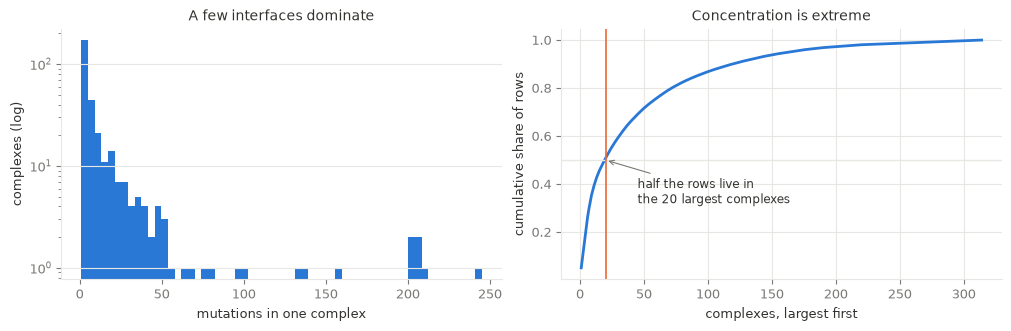

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)

ax1.hist(per_complex.values, bins=60, color=BLUE, edgecolor="none")
ax1.set_yscale("log")
ax1.set_xlabel("mutations in one complex"); ax1.set_ylabel("complexes (log)")
ax1.set_title("A few interfaces dominate", fontsize=10, color=INK)
ax1.grid(True, axis="y")

cum = per_complex.cumsum() / per_complex.sum()
ax2.plot(np.arange(1, len(cum) + 1), cum.values, color=BLUE, lw=2)
ax2.axhline(0.5, color=GRID, lw=1)
n_half = int((cum < 0.5).sum()) + 1
ax2.axvline(n_half, color=ORANGE, lw=1.2)
ax2.annotate(f"half the rows live in\nthe {n_half} largest complexes",
             xy=(n_half, 0.5), xytext=(n_half + 25, 0.32), fontsize=8.5, color=INK,
             arrowprops=dict(arrowstyle="->", color="#7a7975", lw=0.8))
ax2.set_xlabel("complexes, largest first"); ax2.set_ylabel("cumulative share of rows")
ax2.set_title("Concentration is extreme", fontsize=10, color=INK)
ax2.grid(True)
plt.show()

### What that concentration does to a uniform group split

Because group sizes span three orders of magnitude, sampling *groups* uniformly at random
gives wildly uneven *row* counts — the first attempt produced a 227-row (4.7%) validation
set where 15% was intended, far too thin to select a model on.

`split_by_group` therefore shuffles under a fixed seed, takes groups largest-first, and
gives each to whichever split is furthest below its row target. Groups stay atomic, so the
invariant is structural, and all three definitions land on 70/15/15 by row count.

In [8]:
merged = modelled.merge(splits, on="uid")
rows = []
for col, group_key in [("split_mutation", None),
                       ("split_pdb_id", "pdb_id"),
                       ("split_hold_out_proteins", "hold_out_proteins")]:
    counts = merged[col].value_counts()
    total = counts.sum()
    rec = {"split definition": col,
           "groups": merged[group_key].nunique() if group_key else "—"}
    for part in ("train", "val", "test"):
        rec[part] = f"{counts[part]:,} ({counts[part] / total:.1%})"
    rows.append(rec)
pd.DataFrame(rows)

,split definition,groups,train,val,test
0,split_mutation,—,"3,367 (69.9%)",723 (15.0%),724 (15.0%)
1,split_pdb_id,313,"3,374 (70.1%)",725 (15.1%),715 (14.9%)
2,split_hold_out_proteins,152,"3,371 (70.0%)",719 (14.9%),724 (15.0%)


In [9]:
# The invariant itself, checked here rather than taken on trust.
for col, group_key in [("split_pdb_id", "pdb_id"),
                       ("split_hold_out_proteins", "hold_out_proteins")]:
    per_group = merged.groupby(group_key)[col].nunique()
    straddling = per_group[per_group > 1]
    print(f"{col:26s} groups in more than one split: {len(straddling)}")
assert merged.groupby("pdb_id")["split_pdb_id"].nunique().max() == 1
assert merged.groupby("hold_out_proteins")["split_hold_out_proteins"].nunique().max() == 1
print("\nInvariant holds. tests/test_splits.py enforces this as 14 tests in CI.")

split_pdb_id               groups in more than one split: 0
split_hold_out_proteins    groups in more than one split: 0

Invariant holds. tests/test_splits.py enforces this as 14 tests in CI.


## 4. Sequence lengths — where the 2,048-token cap comes from

ESM-2 uses rotary position embeddings, so there is no hard 1,024-token wall; the
`max_position_embeddings: 1026` field in the config is vestigial for this architecture.
The cap is a **compute budget**, chosen to bound worst-case attention.

Truncation was rejected rather than tuned. At a 1,024 cap the mutation site itself falls
outside the window for 77 rows — the wild-type and mutant sequences then tokenize
*identically*, `mut_emb − wt_emb` is exactly zero, and the model trains on a real label with
no signal. That is a silent failure, which is worse than a loud one.

In [10]:
for cap in (1024, 1536, 2048, 4096):
    lost_c = (complexes.n_tokens > cap).sum()
    lost_r = mutations.pdb_field.isin(complexes.loc[complexes.n_tokens > cap, "pdb_field"]).sum()
    mark = "   <-- chosen" if cap == 2048 else ""
    print(f"cap {cap:5}: {lost_c:2} complexes / {lost_r:3} rows lost ({lost_r/len(mutations):.1%}){mark}")

print()
q = complexes.n_tokens.describe(percentiles=[0.5, 0.95])
print(f"median {q['50%']:.0f} tokens, 95th pct {q['95%']:.0f}, max {q['max']:.0f}")

cap  1024: 15 complexes / 189 rows lost (3.9%)
cap  1536:  6 complexes /  75 rows lost (1.6%)
cap  2048:  2 complexes /  15 rows lost (0.3%)   <-- chosen
cap  4096:  0 complexes /   0 rows lost (0.0%)

median 394 tokens, 95th pct 987, max 3399


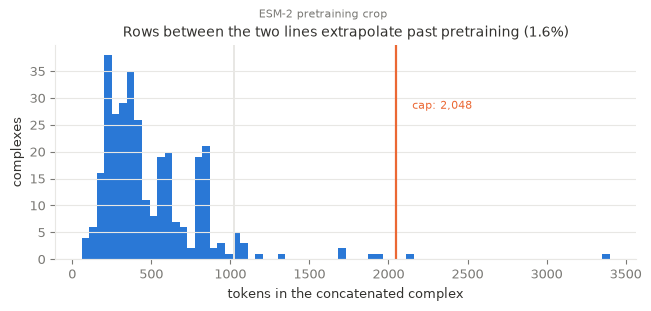

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.0), constrained_layout=True)
ax.hist(complexes.n_tokens, bins=70, color=BLUE, edgecolor="none")
ax.axvline(1024, color=GRID, lw=1.4)
ax.axvline(2048, color=ORANGE, lw=1.6)
ax.annotate("ESM-2 pretraining crop", xy=(1024, 0), xytext=(1180, 45),
            fontsize=8, color="#7a7975")
ax.annotate("cap: 2,048", xy=(2048, 0), xytext=(2150, 28), fontsize=8, color=ORANGE)
ax.set_xlabel("tokens in the concatenated complex"); ax.set_ylabel("complexes")
ax.set_title("Rows between the two lines extrapolate past pretraining (1.6%)",
             fontsize=10, color=INK)
ax.grid(True, axis="y")
plt.show()

## 5. The antibody subset is free

SKEMPI labels each entry's interaction type, so the antibody–antigen breakdown costs
nothing to compute. This subset was pre-specified *before* any results existed, which is
what makes it a planned comparison rather than a subgroup found by searching — and it is
where the fine-tuned model behaves worst.

In [12]:
mutations.hold_out_type.fillna("(unlabelled)").value_counts().to_frame("mutations")

,mutations
hold_out_type,
(unlabelled),2569
Pr/PI,1013
AB/AG,696
TCR/pMHC,491
"AB/AG,Pr/PI",60


---

**Takeaways that shaped the rest of the project**

| observation | consequence |
|---|---|
| 11% of rows beyond \|ΔΔG\| > 3, real measurements | Huber loss, δ = 1.0 |
| A few interfaces carry most of the rows | split by group, never by row; size-aware assignment |
| Group sizes span 3 orders of magnitude | largest-first assignment to hit 70/15/15 on *rows* |
| 127 affinities are bounds, not numbers | filter on the raw columns, not the parsed ones |
| Mutation site can fall outside a 1,024 window | exclude long complexes rather than truncate |